In [3]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path("output/test_count_aggregate.csv")
df = pd.read_csv(CSV_PATH)

print(df.shape)
df.head()


(801, 11)


,Model,Context,Instance,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,BBC01,1,1,NOT_COMPILED,NOT_COMPILED,NOT_VALID,NOT_VALID,NOT_VALID,NOT_VALID
1,GPT4o,Class,BBC02,2,2,NOT_COMPILED,NOT_COMPILED,NOT_VALID,NOT_VALID,NOT_VALID,NOT_VALID
2,GPT4o,Class,BBC03,2,2,1,1,1,1,1,1
3,GPT4o,Class,BBC04,51,91,1,1,1,1,0,0
4,GPT4o,Class,BBC05,4,6,NOT_COMPILED,NOT_COMPILED,NOT_VALID,NOT_VALID,NOT_VALID,NOT_VALID


In [4]:
# confirm which columns have string values
print(df.dtypes)
print()
for col in ["CompiledTestFileCount", "CompiledTestCount", "ExecutedTestFileCount",
            "ExecutedTestCount", "DetectedTestFileCount", "DetectedBCTestCount"]:
    print(col, "->", df[col].unique()[:5])


Model                    object
Context                  object
Instance                 object
TestFileCount             int64
TotalTestCount            int64
CompiledTestFileCount    object
CompiledTestCount        object
ExecutedTestFileCount    object
ExecutedTestCount        object
DetectedTestFileCount    object
DetectedBCTestCount      object
dtype: object

CompiledTestFileCount -> ['NOT_COMPILED' '1' '49' '2' '247']
CompiledTestCount -> ['NOT_COMPILED' '1' '119' '2' '492']
ExecutedTestFileCount -> ['NOT_VALID' '1' '16' '0' '171']
ExecutedTestCount -> ['NOT_VALID' '1' '36' '0' '278']
DetectedTestFileCount -> ['NOT_VALID' '1' '0' '16' '2']
DetectedBCTestCount -> ['NOT_VALID' '1' '0' '36' '2']


Adding 0 as cannot drop the rows, it will miscalculate stuff.

In [5]:
SENTINELS = {"NOT_COMPILED": 0, "NOT_VALID": 0}
NUMERIC_COLS = ["TestFileCount", "TotalTestCount", "CompiledTestFileCount", "CompiledTestCount",
                "ExecutedTestFileCount", "ExecutedTestCount", "DetectedTestFileCount", "DetectedBCTestCount"]

df_clean = df.copy()
for col in NUMERIC_COLS:
    df_clean[col] = df_clean[col].replace(SENTINELS).astype(int)

df_clean.dtypes


Model                    object
Context                  object
Instance                 object
TestFileCount             int64
TotalTestCount            int64
CompiledTestFileCount     int64
CompiledTestCount         int64
ExecutedTestFileCount     int64
ExecutedTestCount         int64
DetectedTestFileCount     int64
DetectedBCTestCount       int64
dtype: object

In [6]:
NUMERIC_COLS = ["TestFileCount", "TotalTestCount", "CompiledTestFileCount", "CompiledTestCount",
                "ExecutedTestFileCount", "ExecutedTestCount", "DetectedTestFileCount", "DetectedBCTestCount"]

modelcontext_df = (
    df_clean
    .groupby(["Model", "Context"], as_index=False)[NUMERIC_COLS]
    .sum()
)

modelcontext_df


,Model,Context,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,5790,9841,1868,3178,968,1528,335,452
1,GPT4o,Method,5790,10252,1684,2845,827,1190,301,393
2,GPT4o,Minimal,5790,6904,1014,1146,414,449,174,178
3,GPTOSS,Class,5790,12382,214,396,150,310,69,109
4,GPTOSS,Method,5790,11287,199,325,108,191,78,126
5,GPTOSS,Minimal,5790,8419,117,157,23,30,8,10
6,Qwen3-coder,Class,5790,14221,1939,4043,1293,2510,727,907
7,Qwen3-coder,Method,5790,12963,1802,3142,1020,1644,671,862
8,Qwen3-coder,Minimal,5790,10283,1721,2291,886,1181,673,717


In [9]:
df_clean.head()
print(df_clean.shape)  # should still be (802, 11)


(801, 11)


In [11]:
modelcontext_df = (
    df_clean
    .groupby(["Model", "Context"])
    .agg(
        InstanceCount=("Instance", "nunique"),
        **{col: (col, "sum") for col in NUMERIC_COLS}
    )
    .reset_index()
)

modelcontext_df


,Model,Context,InstanceCount,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,89,5790,9841,1868,3178,968,1528,335,452
1,GPT4o,Method,89,5790,10252,1684,2845,827,1190,301,393
2,GPT4o,Minimal,89,5790,6904,1014,1146,414,449,174,178
3,GPTOSS,Class,89,5790,12382,214,396,150,310,69,109
4,GPTOSS,Method,89,5790,11287,199,325,108,191,78,126
5,GPTOSS,Minimal,89,5790,8419,117,157,23,30,8,10
6,Qwen3-coder,Class,89,5790,14221,1939,4043,1293,2510,727,907
7,Qwen3-coder,Method,89,5790,12963,1802,3142,1020,1644,671,862
8,Qwen3-coder,Minimal,89,5790,10283,1721,2291,886,1181,673,717


In [12]:
df_clean["ReachedGenerated"] = df_clean["TestFileCount"] > 0
df_clean["ReachedCompiled"]  = df_clean["CompiledTestFileCount"] > 0
df_clean["ReachedExecuted"]  = df_clean["ExecutedTestFileCount"] > 0
df_clean["ReachedDetectedBC"] = df_clean["DetectedBCTestCount"] > 0

df_clean[["Model", "Context", "Instance", "ReachedGenerated", "ReachedCompiled", "ReachedExecuted", "ReachedDetectedBC"]].head()


,Model,Context,Instance,ReachedGenerated,ReachedCompiled,ReachedExecuted,ReachedDetectedBC
0,GPT4o,Class,BBC01,True,False,False,False
1,GPT4o,Class,BBC02,True,False,False,False
2,GPT4o,Class,BBC03,True,True,True,True
3,GPT4o,Class,BBC04,True,True,True,False
4,GPT4o,Class,BBC05,True,False,False,False


In [13]:
STAGE_FLAGS = ["ReachedGenerated", "ReachedCompiled", "ReachedExecuted", "ReachedDetectedBC"]

modelcontext_df = (
    df_clean
    .groupby(["Model", "Context"])
    .agg(
        InstanceCount=("Instance", "nunique"),
        InstancesGenerated=("ReachedGenerated", "sum"),
        InstancesCompiled=("ReachedCompiled", "sum"),
        InstancesExecuted=("ReachedExecuted", "sum"),
        InstancesDetectedBC=("ReachedDetectedBC", "sum"),
        **{col: (col, "sum") for col in NUMERIC_COLS}
    )
    .reset_index()
)

modelcontext_df


,Model,Context,InstanceCount,InstancesGenerated,InstancesCompiled,InstancesExecuted,InstancesDetectedBC,TestFileCount,TotalTestCount,CompiledTestFileCount,CompiledTestCount,ExecutedTestFileCount,ExecutedTestCount,DetectedTestFileCount,DetectedBCTestCount
0,GPT4o,Class,89,89,39,29,27,5790,9841,1868,3178,968,1528,335,452
1,GPT4o,Method,89,89,39,33,13,5790,10252,1684,2845,827,1190,301,393
2,GPT4o,Minimal,89,89,42,36,17,5790,6904,1014,1146,414,449,174,178
3,GPTOSS,Class,89,89,24,20,10,5790,12382,214,396,150,310,69,109
4,GPTOSS,Method,89,89,20,17,8,5790,11287,199,325,108,191,78,126
5,GPTOSS,Minimal,89,89,24,8,4,5790,8419,117,157,23,30,8,10
6,Qwen3-coder,Class,89,89,37,32,20,5790,14221,1939,4043,1293,2510,727,907
7,Qwen3-coder,Method,89,89,37,32,20,5790,12963,1802,3142,1020,1644,671,862
8,Qwen3-coder,Minimal,89,89,36,30,18,5790,10283,1721,2291,886,1181,673,717


create some distribution plot for each model and context variant to see how many tests they generated per instance like a violin plot.

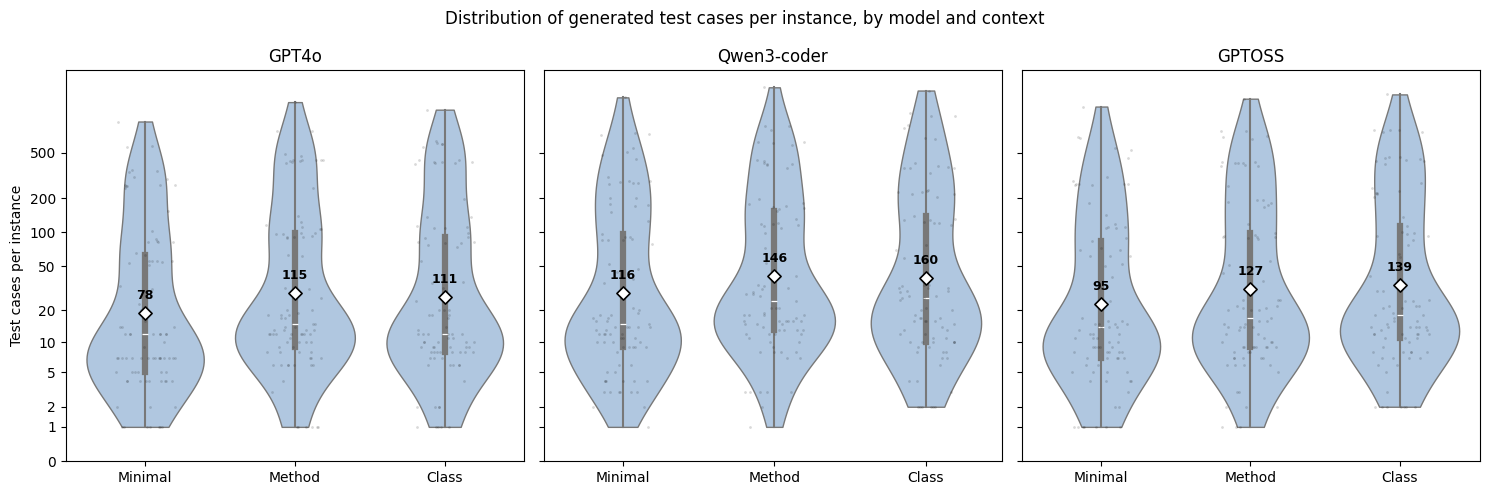

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

plot_df = df_clean.copy()
plot_df["LogTotalTestCount"] = np.log1p(plot_df["TotalTestCount"])

raw_ticks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]
raw_ticks = [t for t in raw_ticks if t <= plot_df["TotalTestCount"].max()]
log_ticks = np.log1p(raw_ticks)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["Model"] == model]

    sns.violinplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, cut=0, inner="box",
        color="#a8c6e8", linewidth=1, ax=ax,
    )

    sns.stripplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax,
        color="black", alpha=0.15, size=2, jitter=0.2,
    )

    means = sub.groupby("Context")["LogTotalTestCount"].mean().reindex(CONTEXT_ORDER)
    raw_means = sub.groupby("Context")["TotalTestCount"].mean().reindex(CONTEXT_ORDER)
    for i, ctx in enumerate(CONTEXT_ORDER):
        ax.scatter(i, means[ctx], marker="D", s=45, color="white",
                   edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(f"{raw_means[ctx]:.0f}", (i, means[ctx]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", zorder=6)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("Test cases per instance")
axes[0].set_yticks(log_ticks)
axes[0].set_yticklabels(raw_ticks)

fig.suptitle("Distribution of generated test cases per instance, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_violin_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()

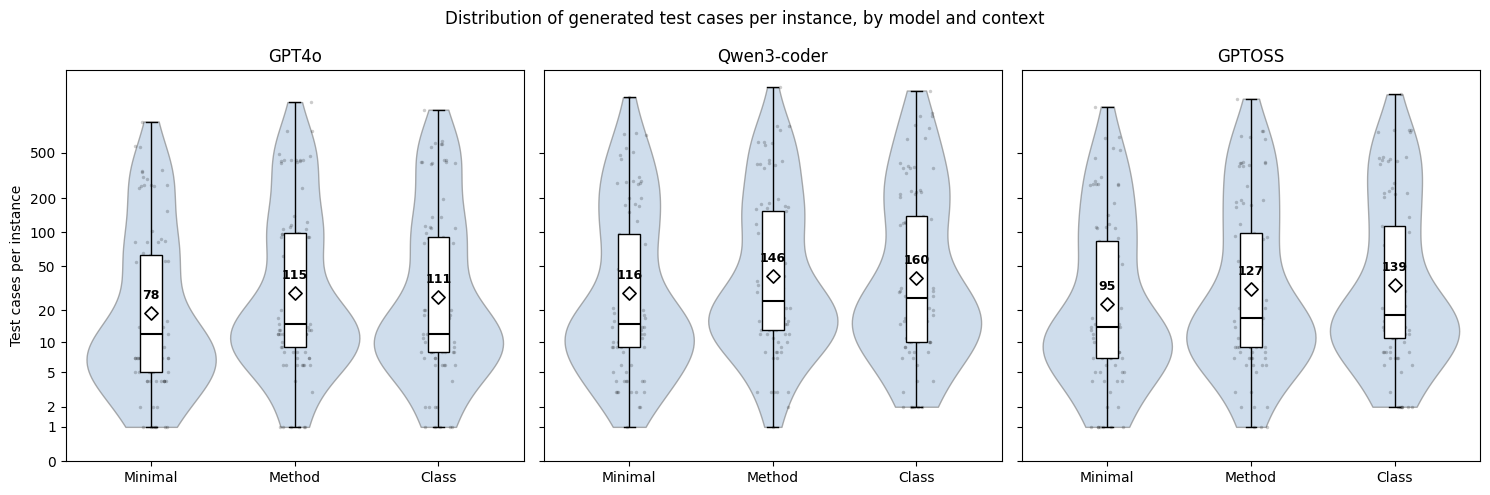

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

plot_df = df_clean.copy()
plot_df["LogTotalTestCount"] = np.log1p(plot_df["TotalTestCount"])

raw_ticks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]
raw_ticks = [t for t in raw_ticks if t <= plot_df["TotalTestCount"].max()]
log_ticks = np.log1p(raw_ticks)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["Model"] == model]

    # half-violin (cloud), shifted right so it doesn't overlap the box
    sns.violinplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, cut=0, inner=None,
        color="#a8c6e8", linewidth=1, ax=ax,
        density_norm="width", width=0.9,
    )
    # shrink and shift each violin half to one side
    for coll in ax.collections:
        coll.set_alpha(0.6)

    # boxplot (narrow, offset left) for exact quartiles
    sns.boxplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax, width=0.15,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
        showfliers=False, zorder=3,
    )

    # raw points (rain), jittered below
    sns.stripplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax,
        color="black", alpha=0.2, size=2.5, jitter=0.12, zorder=1,
    )

    means = sub.groupby("Context")["LogTotalTestCount"].mean().reindex(CONTEXT_ORDER)
    raw_means = sub.groupby("Context")["TotalTestCount"].mean().reindex(CONTEXT_ORDER)
    for i, ctx in enumerate(CONTEXT_ORDER):
        ax.scatter(i, means[ctx], marker="D", s=45, color="white",
                   edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(f"{raw_means[ctx]:.0f}", (i, means[ctx]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", zorder=6)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("Test cases per instance")
axes[0].set_yticks(log_ticks)
axes[0].set_yticklabels(raw_ticks)

fig.suptitle("Distribution of generated test cases per instance, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_raincloud_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()

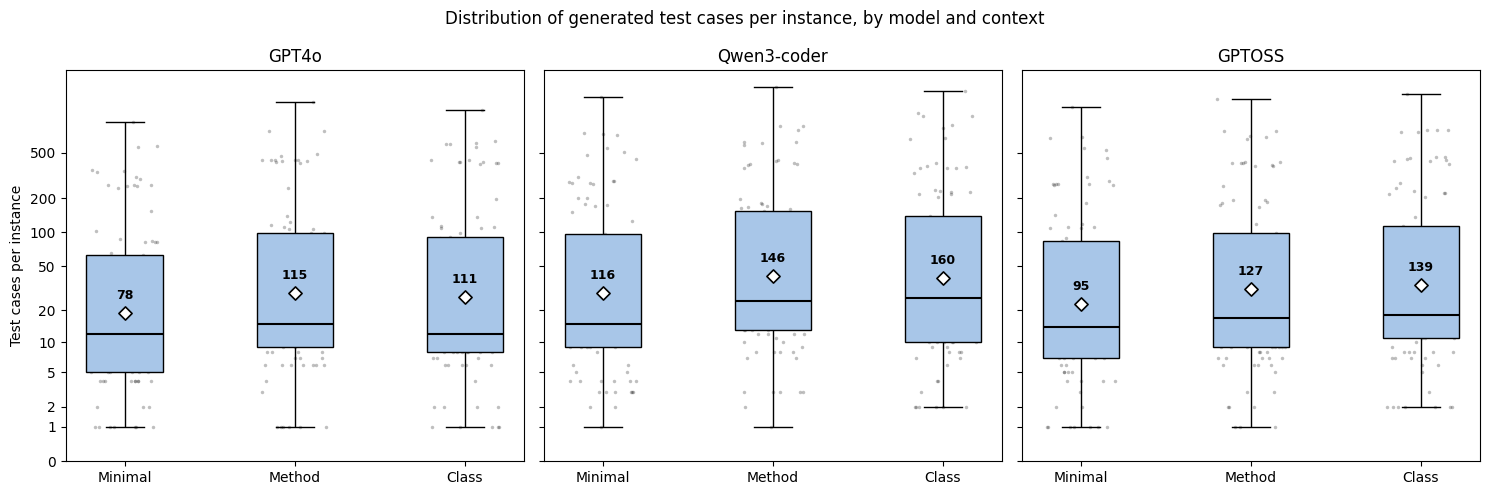

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_ORDER = ["GPT4o", "Qwen3-coder", "GPTOSS"]
CONTEXT_ORDER = ["Minimal", "Method", "Class"]

plot_df = df_clean.copy()
plot_df["LogTotalTestCount"] = np.log1p(plot_df["TotalTestCount"])

raw_ticks = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]
raw_ticks = [t for t in raw_ticks if t <= plot_df["TotalTestCount"].max()]
log_ticks = np.log1p(raw_ticks)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["Model"] == model]

    sns.boxplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax, width=0.45,
        boxprops=dict(facecolor="#a8c6e8", edgecolor="black", linewidth=1),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(color="black"), capprops=dict(color="black"),
        showfliers=False, zorder=2,
    )

    # raw points, jittered, sparse enough to read as texture not clutter
    sns.stripplot(
        data=sub, x="Context", y="LogTotalTestCount",
        order=CONTEXT_ORDER, ax=ax,
        color="black", alpha=0.25, size=2.5, jitter=0.2, zorder=1,
    )

    # mean marker + numeric label per context
    means = sub.groupby("Context")["LogTotalTestCount"].mean().reindex(CONTEXT_ORDER)
    raw_means = sub.groupby("Context")["TotalTestCount"].mean().reindex(CONTEXT_ORDER)
    for i, ctx in enumerate(CONTEXT_ORDER):
        ax.scatter(i, means[ctx], marker="D", s=45, color="white",
                   edgecolor="black", linewidth=1.2, zorder=5)
        ax.annotate(f"{raw_means[ctx]:.0f}", (i, means[ctx]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold", zorder=6)

    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("Test cases per instance")
axes[0].set_yticks(log_ticks)
axes[0].set_yticklabels(raw_ticks)

fig.suptitle("Distribution of generated test cases per instance, by model and context")
fig.tight_layout()
plt.savefig("output/testcount_box_by_model_context.png", dpi=150, bbox_inches="tight")
plt.show()